In [ ]:
!pip install neurokit2 wfdb --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 696.5/696.5 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 60.9 MB/s eta 0:00:00


In [2]:
# STEP 2: Imports and Constants
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import neurokit2 as nk

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, UpSampling1D
)

# Constants
FS_ORIG = 1000          # Original frequency (may vary)
FS_TARGET = 500         # Downsample target
SEG_BEFORE = int(0.32 * FS_TARGET)  # 160 samples before R-peak
SEG_AFTER = int(0.48 * FS_TARGET)   # 240 samples after R-peak
SEG_LEN = SEG_BEFORE + SEG_AFTER    # Total 400 samples

In [3]:
# STEP 3: Pre-processing functions  (Section A)

def bandpass_filter(ecg_signal, fs=FS_TARGET):
    """Finite-Impulse-Response filter: 0.7–90 Hz band-pass (removes 50 Hz noise)."""
    nyq = fs / 2
    b, a = butter(4, [0.7 / nyq, 90 / nyq], btype='band')
    return filtfilt(b, a, ecg_signal)

def segment_heartbeats(ecg, fs=FS_TARGET):
    """
    Build single-heartbeat segments:
    • R-peaks via neurokit2
    • 0.32 s before + 0.48 s after each R-peak (total 400 samples @ 500 Hz)
    • Skip first and last R-peaks
    """
    ecg_clean = nk.ecg_clean(ecg, sampling_rate=fs)
    _, rpeaks = nk.ecg_peaks(ecg_clean, sampling_rate=fs)
    segments = []
    for r in rpeaks["ECG_R_Peaks"][1:-1]:           # discard first & last
        if r - SEG_BEFORE >= 0 and r + SEG_AFTER < len(ecg):
            segments.append(ecg[r-SEG_BEFORE : r+SEG_AFTER])
    return np.asarray(segments)                      # shape: (n_beats, 400)

def normalize_amplitude(segment):
    """Scale each segment so peak-to-peak = 2 mV (paper’s amplitude normalisation)."""
    return segment * (2.0 / np.max(np.abs(segment)))

def generate_template(segments):
    """
    Template = element-wise average of the 5 beats
    with smallest Euclidean distance from the overall mean (paper, step A-3/4).
    """
    mean_seg = segments.mean(axis=0)
    dists = np.linalg.norm(segments - mean_seg, axis=1)
    best5 = segments[np.argsort(dists)[:5]]
    return best5.mean(axis=0)                        # shape: (400,)

# STEP 4: Autoencoder for feature extraction  (Section B)

def build_autoencoder(input_shape=(400, 1)):
    inp = Input(shape=input_shape)

    # Encoder – 4 Conv blocks (paper: conv-BN-ReLU-pool)
    x = Conv1D(32, 7, padding="same")(inp);  x = BatchNormalization()(x);  x = ReLU()(x);  x = MaxPooling1D(2)(x)
    x = Conv1D(64, 5, padding="same")(x);   x = BatchNormalization()(x);  x = ReLU()(x);  x = MaxPooling1D(2)(x)
    x = Conv1D(128, 3, padding="same")(x);  x = BatchNormalization()(x);  x = ReLU()(x);  encoded = MaxPooling1D(2)(x)

    # Decoder – symmetric to encoder
    x = Conv1D(128, 3, padding="same")(encoded); x = BatchNormalization()(x); x = ReLU()(x); x = UpSampling1D(2)(x)
    x = Conv1D(64, 5, padding="same")(x);   x = BatchNormalization()(x); x = ReLU()(x); x = UpSampling1D(2)(x)
    x = Conv1D(32, 7, padding="same")(x);   x = BatchNormalization()(x); x = ReLU()(x); decoded = UpSampling1D(2)(x)

    autoencoder = Model(inp, decoded)
    encoder     = Model(inp, encoded)   # we’ll use this for features
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder

In [4]:
# STEP 5: Load and process yo.csv and 202.csv

from ast import literal_eval
from tqdm import tqdm

# Load data
yo_df = pd.read_csv('/content/drive/MyDrive/ecg/yo.csv')  # Make sure path is correct
test_df = pd.read_csv('/content/drive/MyDrive/ecg/202.csv')

# Process each person's MLII ECG from yo.csv
X_templates = []
y_labels = []

print("🔄 Generating heartbeat templates for each person in yo.csv")
for idx, row in tqdm(yo_df.iterrows(), total=len(yo_df)):
    person_id = row['Person_ID']
    ecg_signal = np.array(literal_eval(row['MLII_segment']), dtype=np.float32)

    # Downsample (if needed) → filter → segment → normalize → template
    ecg_signal = nk.signal_resample(ecg_signal, sampling_rate=FS_ORIG, desired_sampling_rate=FS_TARGET)
    filtered = bandpass_filter(ecg_signal)
    segments = segment_heartbeats(filtered)
    if len(segments) < 5:
        continue  # Skip weak signals
    segments = np.array([normalize_amplitude(seg) for seg in segments])
    template = generate_template(segments)

    X_templates.append(template)
    y_labels.append(person_id)

X_templates = np.array(X_templates)[..., np.newaxis]  # shape: (N, 400, 1)
y_labels = np.array(y_labels)
print(f"✅ Templates shape: {X_templates.shape}, Labels: {y_labels.shape}")

# Prepare test template for person 202
print("🔎 Processing test person 202...")
test_ecg = test_df["'MLII'"].values.astype(np.float32)[:107500]
test_ecg = nk.signal_resample(test_ecg, sampling_rate=FS_ORIG, desired_sampling_rate=FS_TARGET)
test_filtered = bandpass_filter(test_ecg)
test_segments = segment_heartbeats(test_filtered)
test_segments = np.array([normalize_amplitude(seg) for seg in test_segments])
test_template = generate_template(test_segments)[..., np.newaxis]  # shape: (400, 1)

🔄 Generating heartbeat templates for each person in yo.csv


100%|██████████| 47/47 [00:23<00:00,  2.00it/s]

✅ Templates shape: (47, 400, 1), Labels: (47,)
🔎 Processing test person 202...


Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 465ms/step - loss: 0.4635 - val_loss: 0.1069
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - loss: 0.2334 - val_loss: 0.1033
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 245ms/step - loss: 0.1656 - val_loss: 0.0991
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - loss: 0.1218 - val_loss: 0.0954
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 376ms/step - loss: 0.1024 - val_loss: 0.0936
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 264ms/step - loss: 0.0926 - val_loss: 0.0918
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - loss: 0.0824 - val_loss: 0.0916
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - loss: 0.0593 - val_loss: 0.0914
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - loss: 0.0595 - val_loss: 0.0896
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step - loss: 0.0635 - val_loss: 0.0887
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 339ms/step - loss: 0.0660 - val_loss: 0.0893
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 380ms/step - loss: 0.0553 - val_lo

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


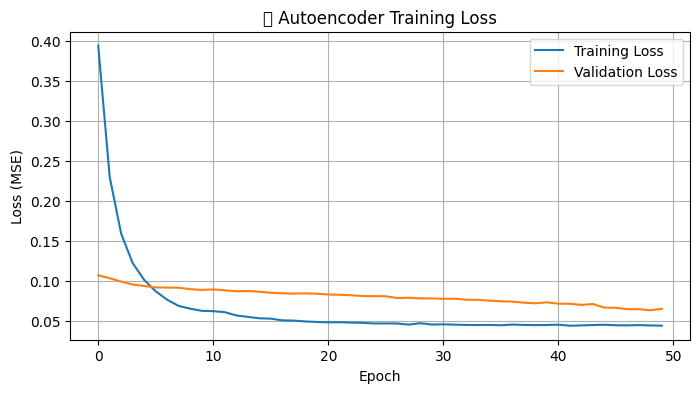

📦 Extracting latent features from encoder...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
✅ Encoded templates shape: (47, 50, 128)
✅ Encoded test sample shape: (1, 50, 128)


In [5]:
autoencoder, encoder = build_autoencoder(input_shape=(400, 1))
autoencoder.compile(optimizer='adam', loss='mse', run_eagerly=True)

# Optional but useful callbacks
from tensorflow.keras.callbacks import EarlyStopping, Callback

class NaNStopping(Callback):
    def on_batch_end(self, batch, logs=None):
        if np.isnan(logs.get('loss', 0)):
            print(f"❌ NaN detected at batch {batch}, stopping training.")
            self.model.stop_training = True

history = autoencoder.fit(
    X_templates, X_templates,
    epochs=50,
    batch_size=8,
    validation_split=0.1,
    verbose=1,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True),
        NaNStopping()
    ]
)

# Plot training curve
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("📉 Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

# Extract latent features from encoder
print("📦 Extracting latent features from encoder...")
encoded_templates = encoder.predict(X_templates)
encoded_test = encoder.predict(test_template[np.newaxis, ...])  # shape: (1, latent_dim)

print(f"✅ Encoded templates shape: {encoded_templates.shape}")
print(f"✅ Encoded test sample shape: {encoded_test.shape}")

In [6]:
print("Any NaNs in encoded_templates?", np.isnan(encoded_templates).any())
print("Any NaNs in encoded_test?", np.isnan(encoded_test).any())

Any NaNs in encoded_templates? False
Any NaNs in encoded_test? False


In [7]:
import ast
import numpy as np
import random
import neurokit2 as nk
from scipy.signal import butter, filtfilt

# Constants
FS_TARGET = 500
SEG_BEFORE = int(0.32 * FS_TARGET)
SEG_AFTER = int(0.48 * FS_TARGET)

# --- ECG Preprocessing: Bandpass + Notch (50 Hz)
def preprocess_ecg(ecg, fs=FS_TARGET):
    nyq = 0.5 * fs
    low, high = 0.7 / nyq, 90 / nyq
    b, a = butter(2, [low, high], btype='band')
    ecg_filtered = filtfilt(b, a, ecg)

    # 50 Hz notch filter
    notch_freq = 50.0
    b_notch, a_notch = butter(2, [(notch_freq - 2)/nyq, (notch_freq + 2)/nyq], btype='bandstop')
    ecg_filtered = filtfilt(b_notch, a_notch, ecg_filtered)

    return ecg_filtered

# --- Segment extraction around R-peaks
def extract_segments(ecg_signal, fs=FS_TARGET, label=None):
    ecg_cleaned = preprocess_ecg(ecg_signal, fs)
    _, rpeaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=fs)
    rpeaks_idx = rpeaks['ECG_R_Peaks'][1:-1]  # drop first & last

    segments, labels = [], []
    for r in rpeaks_idx:
        start, end = r - SEG_BEFORE, r + SEG_AFTER
        if start >= 0 and end <= len(ecg_cleaned):
            beat = ecg_cleaned[start:end]
            segments.append(beat)
            labels.append(label)

    return segments, labels

# --- Collect all segments
all_segments = []
all_labels = []

for i, row in yo_df.iterrows():
    ecg_raw = np.array(ast.literal_eval(row['MLII_segment']))
    ecg_downsampled = ecg_raw[::2]  # downsample 1000Hz ➝ 500Hz
    person_id = row['Person_ID']

    segs, lbls = extract_segments(ecg_downsampled, label=person_id)
    all_segments.extend(segs)
    all_labels.extend(lbls)

print(f"✅ Total extracted segments: {len(all_segments)}")

# --- Create positive and negative training pairs
def create_pairs(segments, labels, num_pairs=1000):
    pairs = []
    pair_labels = []
    unique_ids = np.unique(labels)

    # Map: person_id ➝ list of their segments
    label_to_segments = {label: [] for label in unique_ids}
    for i, seg in enumerate(segments):
        label_to_segments[labels[i]].append(seg)

    for _ in range(num_pairs):
        # Positive pair
        pid = random.choice(unique_ids)
        if len(label_to_segments[pid]) >= 2:
            segs = random.sample(label_to_segments[pid], 2)
            pairs.append([segs[0], segs[1]])
            pair_labels.append(1)

        # Negative pair
        pid1, pid2 = random.sample(list(unique_ids), 2)
        seg1 = random.choice(label_to_segments[pid1])
        seg2 = random.choice(label_to_segments[pid2])
        pairs.append([seg1, seg2])
        pair_labels.append(0)

    return np.array(pairs), np.array(pair_labels)

# 💡 You can now generate training pairs like this:
# pairs, pair_labels = create_pairs(all_segments, all_labels, num_pairs=2000)

✅ Total extracted segments: 10704


In [8]:
# Create training pairs
pairs, pair_labels = create_pairs(all_segments, all_labels, num_pairs=5000)

# Split into left and right inputs
left_ecg = pairs[:, 0]
right_ecg = pairs[:, 1]

# Convert to NumPy arrays and add channel dim: (samples, 400, 1)
left_ecg = np.expand_dims(np.stack(left_ecg), axis=-1)
right_ecg = np.expand_dims(np.stack(right_ecg), axis=-1)
pair_labels = np.array(pair_labels).astype(np.float32)

print("✅ Left ECG shape:", left_ecg.shape)
print("✅ Right ECG shape:", right_ecg.shape)
print("✅ Labels shape:", pair_labels.shape)

✅ Left ECG shape: (10000, 400, 1)
✅ Right ECG shape: (10000, 400, 1)
✅ Labels shape: (10000,)


In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, Flatten, Dense, Dropout, Lambda
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

# --- Siamese encoder
def build_siamese_encoder(input_shape=(400, 1)):
    inp = Input(shape=input_shape)
    x = Conv1D(32, 7, padding='same')(inp)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(64, 5, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(128, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling1D(2)(x)

    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    return Model(inp, x, name="SiameseEncoder")

# --- Distance function
def euclidean_distance(vects):
    x, y = vects
    return K.sqrt(K.sum(K.square(x - y), axis=1, keepdims=True))

# --- Build Siamese model
input_shape = (400, 1)
encoder = build_siamese_encoder(input_shape)

left_input = Input(shape=input_shape)
right_input = Input(shape=input_shape)

encoded_left = encoder(left_input)
encoded_right = encoder(right_input)

distance = Lambda(euclidean_distance)([encoded_left, encoded_right])
output = Dense(1, activation='sigmoid')(distance)

siamese_model = Model(inputs=[left_input, right_input], outputs=output)
siamese_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

siamese_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 400, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 400, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SiameseEncoder      │ (None, 256)       │  1,674,816 │ input_layer_2[0]… │
│ (Functional)        │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ SiameseEncoder[0… │
│                     │                   │            │ SiameseEncoder[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │          2 │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,674,818 (6.39 MB)

 Trainable params: 1,674,370 (6.39 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
print(np.isnan(left_ecg).any(), np.isnan(right_ecg).any())
print(np.isinf(left_ecg).any(), np.isinf(right_ecg).any())

False False
False False


In [11]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, Flatten, Dense, Lambda
import tensorflow.keras.backend as K
import tensorflow as tf

# Shared CNN feature extractor
def build_shared_cnn(input_shape=(400, 1)):
    inp = Input(shape=input_shape)
    x = Conv1D(32, 5, activation='relu')(inp)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)

    x = Conv1D(64, 3, activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)

    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)

    return Model(inp, x, name="SharedCNN")

# Distance function
def euclidean_distance(vectors):
    x, y = vectors
    return K.sqrt(K.maximum(K.sum(K.square(x - y), axis=1, keepdims=True), K.epsilon()))

# Siamese network
input_shape = (400, 1)
shared_cnn = build_shared_cnn(input_shape)

input_a = Input(shape=input_shape)
input_b = Input(shape=input_shape)

encoded_a = shared_cnn(input_a)
encoded_b = shared_cnn(input_b)

distance = Lambda(euclidean_distance)([encoded_a, encoded_b])
output = Dense(1, activation='sigmoid')(distance)

model = Model(inputs=[input_a, input_b], outputs=output)

In [12]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, Flatten, Dense, Lambda
import tensorflow.keras.backend as K
import tensorflow as tf

# Shared CNN feature extractor
def build_shared_cnn(input_shape=(400, 1)):
    inp = Input(shape=input_shape)
    x = Conv1D(32, 5, activation='relu')(inp)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)

    x = Conv1D(64, 3, activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)

    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)

    return Model(inp, x, name="SharedCNN")

# Euclidean distance function with stability
def euclidean_distance(vectors):
    x, y = vectors
    return K.sqrt(K.maximum(K.sum(K.square(x - y), axis=1, keepdims=True), K.epsilon()))

# Siamese model
input_shape = (400, 1)
shared_cnn = build_shared_cnn(input_shape)

input_a = Input(shape=input_shape)
input_b = Input(shape=input_shape)

encoded_a = shared_cnn(input_a)
encoded_b = shared_cnn(input_b)

distance = Lambda(euclidean_distance)([encoded_a, encoded_b])
output = Dense(1, activation='sigmoid')(distance)

model = Model(inputs=[input_a, input_b], outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 400, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 400, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SharedCNN           │ (None, 128)       │    809,728 │ input_layer_8[0]… │
│ (Functional)        │                   │            │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ SharedCNN[0][0],  │
│                     │                   │            │ SharedCNN[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │          2 │ lambda_2[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 809,730 (3.09 MB)

 Trainable params: 809,538 (3.09 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8804 - loss: 0.3243

125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - accuracy: 0.8803 - loss: 0.3243 - val_accuracy: 0.8195 - val_loss: 0.4404
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8819 - loss: 0.3219

125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - accuracy: 0.8819 - loss: 0.3220 - val_accuracy: 0.8220 - val_loss: 0.4293
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - accuracy: 0.8876 - loss: 0.3077 - val_accuracy: 0.5225 - val_loss: 1.8083
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8761 - loss: 0.3210

125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.8761 - loss: 0.3209 - val_accuracy: 0.8310 - val_loss: 0.4052
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - accuracy: 0.8824 - loss: 0.3111 - val_accuracy: 0.5375 - val_loss: 0.9044
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.8731 - loss: 0.3107 - val_accuracy: 0.6745 - val_loss: 0.7099
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8851 - loss: 0.2897

125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - accuracy: 0.8851 - loss: 0.2897 - val_accuracy: 0.8405 - val_loss: 0.3918
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8950 - loss: 0.2860

125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.8949 - loss: 0.2861 - val_accuracy: 0.8405 - val_loss: 0.3899
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8942 - loss: 0.2783

125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - accuracy: 0.8941 - loss: 0.2784 - val_accuracy: 0.8405 - val_loss: 0.3814
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 133ms/step - accuracy: 0.8954 - loss: 0.2789 - val_accuracy: 0.8415 - val_loss: 0.3834
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - accuracy: 0.8891 - loss: 0.2846 - val_accuracy: 0.8315 - val_loss: 0.4171
Epoch 12/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - accuracy: 0.8943 - loss: 0.2737 - val_accuracy: 0.8110 - val_loss: 0.4564
Epoch 13/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - accuracy: 0.8905 - loss: 0.2773 - val_accuracy: 0.7900 - val_loss: 0.5160


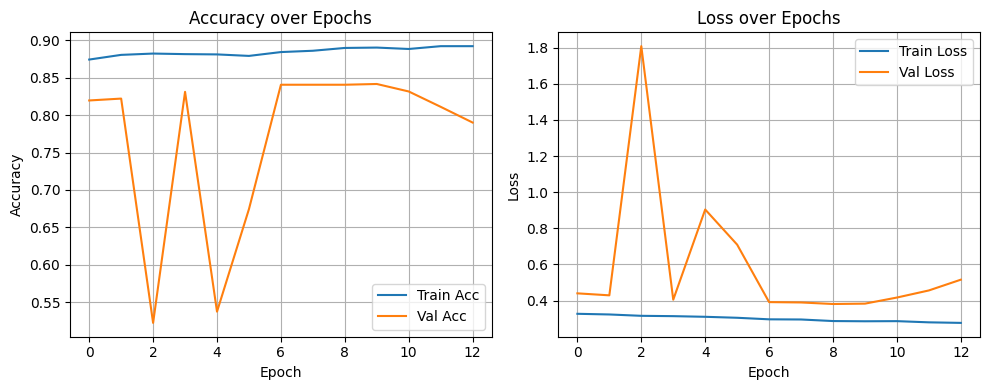

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

# 1. Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_siamese_model.h5", monitor="val_loss", save_best_only=True)

# 2. Normalize ECG input globally (optional: see note below for per-sample)
left_ecg_norm = left_ecg.astype(np.float32)
right_ecg_norm = right_ecg.astype(np.float32)

left_ecg_norm = (left_ecg_norm - np.min(left_ecg_norm)) / (np.max(left_ecg_norm) - np.min(left_ecg_norm) + 1e-6)
right_ecg_norm = (right_ecg_norm - np.min(right_ecg_norm)) / (np.max(right_ecg_norm) - np.min(right_ecg_norm) + 1e-6)

# 3. Train the model with callbacks
history = model.fit(
    [left_ecg_norm, right_ecg_norm], pair_labels,
    validation_split=0.2,
    batch_size=64,
    epochs=20,
    verbose=1,
    callbacks=[early_stop, checkpoint]  # 👈 callbacks added
)

# 4. Plot accuracy and loss
plt.figure(figsize=(10, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
summary_templates = []
summary_labels = []

for idx, row in yo_df.iterrows():
    person_id = row['Person_ID']
    ecg_signal = np.array(ast.literal_eval(row['MLII_segment']), dtype=np.float32)
    ecg_signal = nk.signal_resample(ecg_signal, sampling_rate=FS_ORIG, desired_sampling_rate=FS_TARGET)
    filtered = bandpass_filter(ecg_signal)
    segments = segment_heartbeats(filtered)

    if len(segments) < 10:
        continue  # Skip weak signals

    # Normalize all
    segments = [normalize_amplitude(seg) for seg in segments]

    # Build summary segments (group of 10 beats → template)
    for i in range(0, len(segments) - 9, 10):
        block = segments[i:i+10]
        summary = generate_template(np.array(block))
        summary_templates.append(summary)
        summary_labels.append(person_id)

# Finalize
summary_templates = np.array(summary_templates)[..., np.newaxis]
summary_labels = np.array(summary_labels)
print(f"✅ Summary templates shape: {summary_templates.shape}")

✅ Summary templates shape: (955, 400, 1)


In [17]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np

# ✅ Encode all templates using the trained encoder
encoded_summary = encoder.predict(summary_templates)
X_flat = encoded_summary.reshape(len(encoded_summary), -1)

# ✅ Remove rows with NaNs if any
valid_idx = ~np.isnan(X_flat).any(axis=1)
X_flat_clean = X_flat[valid_idx]
summary_labels_clean = summary_labels[valid_idx]

# ✅ Label encode person IDs
le = LabelEncoder()
y_encoded = le.fit_transform(summary_labels_clean)

# ✅ Train classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X_flat_clean, y_encoded)

# ✅ Encode the test ECG template (should be done same way as summary)
encoded_test = encoder.predict(test_template[np.newaxis, ...])
X_test_flat = encoded_test.reshape(1, -1)

# ✅ Predict person
y_pred_class = clf.predict(X_test_flat)
predicted_id = le.inverse_transform(y_pred_class)[0]
print(f"\n🔍 Predicted Person ID for test ECG: **{predicted_id}**")

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step

🔍 Predicted Person ID for test ECG: **115**


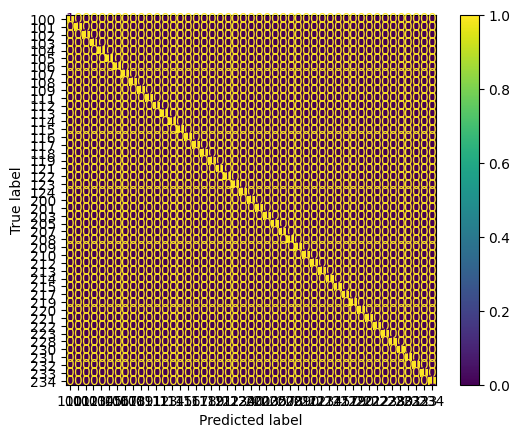

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_train_pred = clf.predict(X_flat)
cm = confusion_matrix(y_encoded, y_train_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()